# Aufgabe 2

In [6]:
# Imports und Experimentparameter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.fft import fft, fftshift, fftfreq
import warnings
warnings.filterwarnings('ignore')

# experimentelle Konstanten (wie in Aufgabe 1)
lambda_ = 636e-9       # Laserwellenlänge in m
f = 0.308              # Brennweite in m
pixel_size = 14e-6     # Pixelgröße in m

# Dateipfade (Aufnahme 1 mm und 2 mm Beispielnamen aus Repo)
fn1 = 'O17 Messdaten/Aufgabe 2/DoppelspatlBeugung01mm.csv'  # Achtung: Dateiname in Repo enthält ein 'l'
fn2 = 'O17 Messdaten/Aufgabe 2/DoppelspaltBeugung02mm.csv'

# Prüfe Verfügbarkeit
for p in [fn1, fn2]:
    try:
        _ = pd.read_csv(p)
    except Exception as e:
        print(f'Warnung: Datei {p} konnte nicht gelesen werden: {e}')


### (a) Spaltabstand g aus Lage der Minima verschiedener Ordnungen
In Aufgabe 2a) soll der Spaltabstand mittels Linearer Regression ermittelt werden. Dabei müssen wir die symmetrische Minima links/rechts vom Hauptmaximum suchen sowie berechnen und $2x_n$ für mehrere Ordnungen $n$ führen eine lineare Regression gegen $(n+0.5)$ machen.  
Aus der Beziehung $2 x_n = \frac{2 f \lambda}{g} (n + 0.5)$ folgt für die Steigung m: $m = \frac{2 f \lambda}{g}$ und damit $g = \frac{2 f \lambda}{m}$.

Dabei kommen wir auf einen Spaltabstand von $g=0.3401$ mm.


Berechneter Spaltabstand g = 0.3401 mm


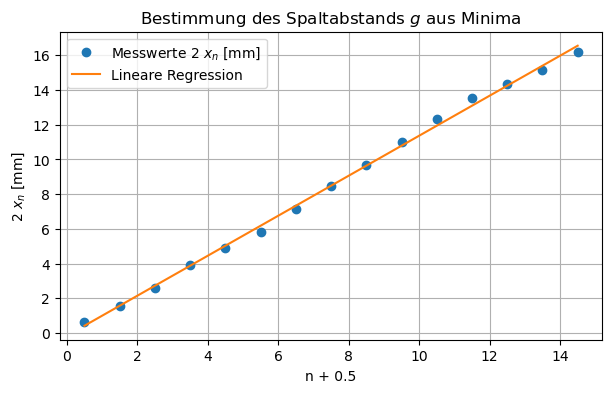

In [15]:
# --- (a) Minima finden und lineare Regression ---

# Wähle Messdatei (primär die 02mm Messung, falls vorhanden)
data_file = fn1

# Einlesen
df = pd.read_csv(data_file)
x_px = df['x'].values
I_raw = df['y'].values.astype(float)

# leichte Glättung
kernel = np.ones(7) / 7.0
I = np.convolve(I_raw, kernel, mode='same')

# Hauptmaximum bestimmen
peaks, _ = find_peaks(I)
idx_max = peaks[np.argmax(I[peaks])]
x0_px = x_px[idx_max]

# Minima als Peaks in -I
minima_idx, _ = find_peaks(-I, distance=5)
minima_left = minima_idx[minima_idx < idx_max]
minima_right = minima_idx[minima_idx > idx_max]

# Wähle paarweise Minima symmetrisch
Npairs = min(len(minima_left), len(minima_right))
pairs = []
two_x = []
for n in range(Npairs):
    il = minima_left[::-1][n]
    ir = minima_right[n]
    xl = (il - x0_px) * pixel_size
    xr = (ir - x0_px) * pixel_size
    pairs.append((il, ir))
    two_x.append(abs(xr - xl))

two_x = np.array(two_x)
n_vals = np.arange(len(two_x))
independent = n_vals + 0.5

# lineare Regression
m, c = np.polyfit(independent, two_x, 1)
g_from_minima = 2 * f * lambda_ / m

#print('--- Ergebnis (a): Spaltabstand aus Minima (Regression) ---')
#print(f'Verwenden: {data_file}')
#for i, (il, ir) in enumerate(pairs):
#    print(f'Ordnung n={i}: Minima px (links,right)=({il},{ir}), 2x_n = {two_x[i]*1e3:.3f} mm')
#print('\nRegression: 2 x_n = m*(n+0.5) + c')
#print(f'm = {m:.3e} m, c = {c:.3e} m')
print(f'Berechneter Spaltabstand g = {g_from_minima*1e3:.4f} mm')

# Plot
plt.figure(figsize=(7,4))
plt.plot(independent, two_x*1e3, 'o', label='Messwerte 2 $x_n$ [mm]')
x_lin = np.linspace(independent.min(), independent.max(), 50)
plt.plot(x_lin, (m*x_lin + c)*1e3, '-', label='Lineare Regression')
plt.xlabel('n + 0.5')
plt.ylabel('2 $x_n$ [mm]')
plt.title('Bestimmung des Spaltabstands $g$ aus Minima')
plt.legend()
plt.grid(True)
plt.show()


### (c) FFT-Methode: Spaltabstand g und Spaltbreite b aus der FFT der Intensitätsverteilung

Wir berechnen die Fourier-Transformation (FFT) der gemessenen Intensitätsverteilung. Die FFT wandelt das Signal in den Frequenzraum, wobei die Position der Hauptpeaks direkt mit dem Spaltabstand $g$ zusammenhängt, dabei liegen die Peaks bei $\pm g/2$. Die Breite des zentralen Maximums (Autokorrelations-Basisbreite) in der FFT ist umgekehrt proportional zur Spaltbreite $b$. Je schmaler der Spalt, desto breiter ist das zentrale Maximum in der Fourier-Transformierten. Deshalb kann man aus der Basisbreite eine Schätzung für $b$ erhalten.

So kommen wir für den Spaltabstand $g = 0.3006$ mm und als Schätzung aus der Autokorrelation auf einen Spaltbreit von $b = 143.47$ µm.

Schätzung g (FFT) = 0.3006 mm
Schätzung b (FFT, aus Autokorrelation) = 143.47 µm


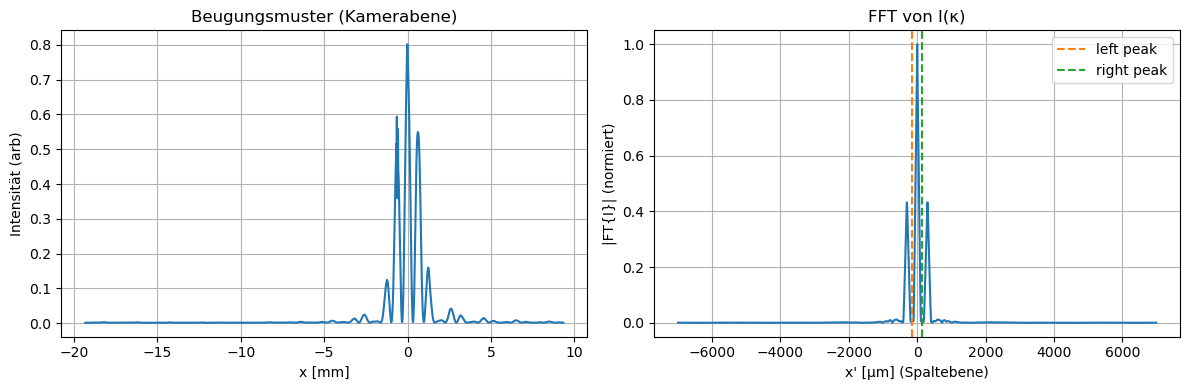

In [21]:
# --- (c) FFT-Analyse ---

df = pd.read_csv(data_file)
x_px = df['x'].values
I_raw = df['y'].values.astype(float)

# Center auf Hauptmaximum
I_smooth = np.convolve(I_raw, np.ones(9)/9, mode='same')
peaks, _ = find_peaks(I_smooth)
idx_max = peaks[np.argmax(I_smooth[peaks])]
x0_px = x_px[idx_max]

x_cam = (x_px - x0_px) * pixel_size  # m
kappa = x_cam / (lambda_ * f)  # Raumfrequenz sin(alpha)/lambda
d_kappa = np.mean(np.diff(kappa))

I_k = I_smooth
G = fft(I_k) * d_kappa
G_shift = fftshift(G)
x_prime = fftshift(fftfreq(len(I_k), d=d_kappa))  # x' in meters (Spaltebene)
mag = np.abs(G_shift)

# Finde Peaks in |FT{I}| (Peaks bei +/- g/2 oder Abständen ~g anzeigen)
peak_idx, _ = find_peaks(mag, height=0.1*mag.max())
if len(peak_idx) >= 2:
    center = len(mag)//2
    lefts = peak_idx[peak_idx < center]
    rights = peak_idx[peak_idx > center]
    if len(lefts) and len(rights):
        il = lefts[-1]
        ir = rights[0]
        x_left = x_prime[il]
        x_right = x_prime[ir]
        g_fft = abs(x_right - x_left)
    else:
        g_fft = np.nan
else:
    g_fft = np.nan

# Abschätzung b aus Autokorrelations-Basisbreite
mag_smooth = np.convolve(mag/ mag.max(), np.ones(21)/21, mode='same')
thr = 0.05
center_idx = np.argmax(mag_smooth)
left_idx = np.where((np.arange(len(mag_smooth)) < center_idx) & (mag_smooth < thr))[0]
right_idx = np.where((np.arange(len(mag_smooth)) > center_idx) & (mag_smooth < thr))[0]
if left_idx.size and right_idx.size:
    left_i = left_idx[-1]
    right_i = right_idx[0]
    width_support = x_prime[right_i] - x_prime[left_i]  # ~ 2 b (m)
    b_fft = width_support / 2.0
else:
    b_fft = np.nan

#print('--- Ergebnis (c): FFT-Methode ---')
print(f'Schätzung g (FFT) = {g_fft*1e3 / 2:.4f} mm')
print(f'Schätzung b (FFT, aus Autokorrelation) = {b_fft*1e6:.2f} µm')

# Plot: I(x) und |FT{I}| (x' in µm)
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(x_cam*1e3, I_raw, label='raw')
ax[0].set_xlabel('x [mm]')
ax[0].set_ylabel('Intensität (arb)')
ax[0].set_title('Beugungsmuster (Kamerabene)')
ax[0].grid(True)

ax[1].plot(x_prime*1e6, mag/ mag.max())
ax[1].set_xlabel("x' [µm] (Spaltebene)")
ax[1].set_ylabel('|FT{I}| (normiert)')
ax[1].set_title('FFT von I(κ)')
ax[1].grid(True)
if not np.isnan(g_fft):
    ax[1].axvline(x=(x_left*1e6/2), color='C1', linestyle='--', label='left peak')
    ax[1].axvline(x=(x_right*1e6/2), color='C2', linestyle='--', label='right peak')
    ax[1].legend()
plt.tight_layout()
plt.show()


### (b) Nichtlinearer Fit: Bestimmung von b und g durch Fit des Fraunhofer-Modells

In Teilaufgbae (b) soll das folgende Modell gefitteted werrden um auch den Spaltabstadn und die SPaltbreite zu erhalten.

$$I(x) = A\cdot\mathrm{sinc}^2\!\left(\pi\sin\alpha\frac{b}{\lambda}\right)\cdot\cos^2\!\left(\pi\sin\alpha\frac{g}{\lambda}\right)+\mathrm{bg}$$

mit der kleinen Winkel‑Approximation $\sin\alpha\approx x/f$ die wir nutzen dürfen, da wir uns im Fernfeld bzw. Frauenhofer_Grenzfall befinden. Dabei sind A die Amplitude, bg der Hintergrund, b als Spaltbreite und g als Spaltabstand freie Fitparameter. Jedoch werden als Anfangswerte bei $b$ und $g$ die Ermittelten Werte von Teilaufgabe (a) und (c) genommen.

Damit gewinnt man verlässliche Schätzwerte für b und g, einschließlich eine Fehlerabschätzungen aus der Kovarianzmatrix.

So erhalten wir aus dem Fit eine Spaltbreite $b = 102.57 \pm 0.77$ µm sowie einen Spaltabstand $g=0.3008 \pm 0.0006$ mm

--- Ergebnis (b): Nichtlinearer Fit ---
A = 7.749e-01 (±5.57e-03)
bg = 3.083e-03 (±2.30e-03)
b = 102.57 µm (±0.77 µm)
g = 0.3008 mm (±0.0006 mm)


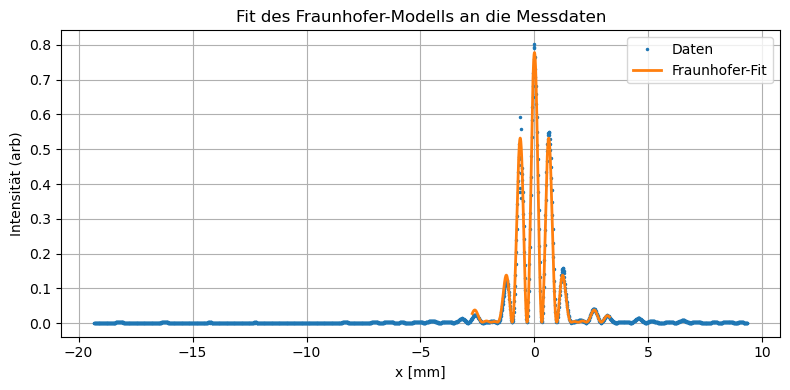

In [ ]:
# --- (b) Fit des Fraunhofer-Modells ---

# Auswahl des Fitbereichs: dort, wo I > 2% des Maximums
mask = I_raw > 0.02 * I_raw.max()
if np.sum(mask) < 10:
    mask = np.ones_like(I_raw, dtype=bool)
x_fit = x_cam[mask]
y_fit = I_raw[mask]

def fraunhofer_model(x, A, bg, b, g):
    sinalpha = x / f
    env = np.sinc(sinalpha * b / lambda_)**2
    carrier = np.cos(np.pi * sinalpha * g / lambda_)**2
    return A * env * carrier + bg

# Startwerte
A0 = y_fit.max()
bg0 = np.median(y_fit[:10])
b0 = b_fft if (not np.isnan(b_fft)) else 5e-4
g0 = g_from_minima if (not np.isnan(g_from_minima)) else (g_fft if (not np.isnan(g_fft)) else 2e-3)

p0 = [A0, bg0, b0, g0]

bounds_lower = [0.0, 0.0, 1e-6, 1e-5]
bounds_upper = [np.inf, np.inf, 5e-2, 5e-2]
try:
    popt, pcov = curve_fit(fraunhofer_model, x_fit, y_fit, p0=p0, bounds=(bounds_lower, bounds_upper), maxfev=20000)
    A_fit, bg_fit, b_fit, g_fit = popt
    perr = np.sqrt(np.diag(pcov))
except Exception as e:
    print('Fit fehlgeschlagen:', e)
    A_fit, bg_fit, b_fit, g_fit = (np.nan,)*4
    perr = [np.nan]*4

#print('--- Ergebnis (b): Nichtlinearer Fit ---')
#print(f'A = {A_fit:.3e} (±{perr[0]:.2e})')
#print(f'bg = {bg_fit:.3e} (±{perr[1]:.2e})')
print(f'b = {b_fit*1e6:.2f} µm (±{perr[2]*1e6 if not np.isnan(perr[2]) else np.nan:.2f} µm)')
print(f'g = {g_fit*1e3:.4f} mm (±{perr[3]*1e3 if not np.isnan(perr[3]) else np.nan:.4f} mm)')

# Plot
x_plot = np.linspace(x_fit.min(), x_fit.max(), 2000)
y_model_plot = fraunhofer_model(x_plot, A_fit, bg_fit, b_fit, g_fit)
plt.figure(figsize=(8,4))
plt.plot(x_cam*1e3, I_raw, '.', markersize=3, label='Daten')
plt.plot(x_plot*1e3, y_model_plot, '-', label='Fraunhofer-Fit', linewidth=2)
plt.xlabel('x [mm]')
plt.ylabel('Intensität (arb)')
plt.title('Fit des Fraunhofer-Modells an die Messdaten')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Zusammenfassung der Resultate
Wie man sieht erhalten wir für jede Teilaufgabe, auf ähnliche Werte kommen was auf gute Messdaten hinweist. Als finale Endwerte nehmen wir den Durchschnitt und erhalten so:
$$g = 3.138 \text{mm} ~~ \text{ und } ~~ b = 1.230 \text{µm}$$